# Indução de Regras de Classificação

Este notebook implementa a extração e análise de **regras de classificação** usando duas abordagens:

1. **Regras da Árvore de Decisão** — cada caminho raiz→folha como regra explícita
2. **Algoritmo Apriori** — indução direta de regras a partir dos dados

Métricas avaliadas (conforme slides do professor):
- **Cobertura** = N_C / N — representatividade da regra na amostra
- **Confiança** = N_AC / N_C — qualidade preditiva (% da classe-alvo na regra)
- **Lift** = Confiança_regra / Confiança_amostra — ganho sobre o acaso
- **p-value** — significância estatística via teste binomial

In [2]:
!pip install mlxtend


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
from scipy.stats import binomtest
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from mlxtend.frequent_patterns import apriori, association_rules


ARQUIVO = 'nij-challenge2021_full_dataset.csv'
LABEL   = 'Recidivism_Within_3years'
SEED    = 42

sns_style = {'axes.spines.top': False, 'axes.spines.right': False}
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12,
                     'axes.labelsize': 10, 'figure.figsize': (10, 5)})


In [3]:
# =============================================================================
# LEITURA E PREPARAÇÃO DOS DADOS
# =============================================================================

df_raw = pd.read_csv(ARQUIVO)

REMOVER = [
    'ID', 'Training_Sample',
    'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3',
    '_v1', '_v2', '_v3', '_v4',
    'Residence_PUMA',
]
df = df_raw.drop(columns=REMOVER).copy()
df[LABEL] = df[LABEL].map({'Yes': 1, 'No': 0}).astype(int)

# ── Mapeamento ordinal (string -> inteiro preservando a ordem) ──────────────
MAPA_ORDINAIS = {
    'Prior_Arrest_Episodes_Felony':    {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Prior_Arrest_Episodes_Misd':      {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6 or more':6},
    'Prior_Arrest_Episodes_Violent':   {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Arrest_Episodes_Property':  {'0':0,'1':1,'2':2,'3':3,'4':4,'5 or more':5},
    'Prior_Arrest_Episodes_Drug':      {'0':0,'1':1,'2':2,'3':3,'4':4,'5 or more':5},
    'Prior_Conviction_Episodes_Felony':{'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Misd':  {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Prior_Conviction_Episodes_Prop':  {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Drug':  {'0':0,'1':1,'2 or more':2},
    'Delinquency_Reports':             {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Program_Attendances':             {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Program_UnexcusedAbsences':       {'0':0,'1':1,'2':2,'3 or more':3},
    'Residence_Changes':               {'0':0,'1':1,'2':2,'3 or more':3},
    'Dependents':                      {'0':0,'1':1,'2':2,'3 or more':3},
}
for col, mapa in MAPA_ORDINAIS.items():
    df[col] = df[col].map(mapa)

# ── Binárias Yes/No -> 0/1 ──────────────────────────────────────────────────
BINARIAS_YESNO = [
    'Gang_Affiliated', 'Prior_Arrest_Episodes_DVCharges',
    'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Viol',
    'Prior_Revocations_Parole', 'Prior_Revocations_Probation',
    'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other',
    'Violations_ElectronicMonitoring', 'Violations_Instruction',
    'Violations_FailToReport', 'Violations_MoveWithoutPermission',
    'Employment_Exempt',
]
for col in BINARIAS_YESNO:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

BINARIAS_ORIGIN_CAT = [c for c in BINARIAS_YESNO if df[c].isnull().any()]

# ── Nominais: Label Encoding mantendo NaN como NaN ──────────────────────────
NOMINAIS = ['Gender', 'Race', 'Age_at_Release', 'Supervision_Level_First',
            'Education_Level', 'Prison_Offense', 'Prison_Years']
le_dict = {}
for col in NOMINAIS:
    le = LabelEncoder()
    le.fit(df[col].dropna().astype(str))
    df[col] = df[col].apply(lambda x: le.transform([str(x)])[0] if pd.notna(x) else np.nan)
    le_dict[col] = le

# ── Tratamento de valores ausentes ──────────────────────────────────────────
# Categóricas (binárias + nominais com NaN): recebem categoria sentinela -1
# Numéricas e ordinais: preenchidas com mediana
NOMINAIS_COM_NULOS   = [c for c in NOMINAIS if df[c].isnull().any()]
CATEGORICAS_FLOAT    = set(BINARIAS_ORIGIN_CAT + NOMINAIS_COM_NULOS)

for col in df.columns:
    if col == LABEL or df[col].isnull().sum() == 0:
        continue
    if df[col].dtype in ['float64', 'int64'] and col not in CATEGORICAS_FLOAT:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(-1)   # -1 = categoria "Missing"

# ── Transformações: DrugTests -> binária; Percent_Days_Employed -> 3 cat. ───
DROGAS_COLS = ['DrugTests_THC_Positive', 'DrugTests_Cocaine_Positive',
               'DrugTests_Meth_Positive', 'DrugTests_Other_Positive']
for col in DROGAS_COLS:
    df[col] = (df[col] > 0).astype(int)   # 0 = nunca positivo | 1 = algum positivo

def cat_emprego(x):
    if x == 0:   return 0   # Desempregado
    elif x == 1: return 2   # Emprego Total
    else:        return 1   # Emprego Parcial

df['Percent_Days_Employed'] = df['Percent_Days_Employed'].apply(cat_emprego)

print(f"Dataset pronto: {df.shape[0]:,} registros x {df.shape[1]} colunas")
print(f"Valores ausentes restantes: {df.isnull().sum().sum()}")
print(f"\nDistribuição da variável resposta:")
vc = df[LABEL].value_counts()
print(f"  Reincidiu (1):     {vc[1]:>6,} ({vc[1]/len(df)*100:.1f}%)")
print(f"  Não reincidiu (0): {vc[0]:>6,} ({vc[0]/len(df)*100:.1f}%)")


Dataset pronto: 25,835 registros x 44 colunas
Valores ausentes restantes: 0

Distribuição da variável resposta:
  Reincidiu (1):     14,904 (57.7%)
  Não reincidiu (0): 10,931 (42.3%)


In [6]:
pd.set_option('display.max_columns', None)
df.head()

,Gender,Race,Age_at_Release,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,Prison_Years,Prior_Arrest_Episodes_Felony,Prior_Arrest_Episodes_Misd,Prior_Arrest_Episodes_Violent,Prior_Arrest_Episodes_Property,Prior_Arrest_Episodes_Drug,Prior_Arrest_Episodes_DVCharges,Prior_Arrest_Episodes_GunCharges,Prior_Conviction_Episodes_Felony,Prior_Conviction_Episodes_Misd,Prior_Conviction_Episodes_Viol,Prior_Conviction_Episodes_Prop,Prior_Conviction_Episodes_Drug,Prior_Revocations_Parole,Prior_Revocations_Probation,Condition_MH_SA,Condition_Cog_Ed,Condition_Other,Violations_ElectronicMonitoring,Violations_Instruction,Violations_FailToReport,Violations_MoveWithoutPermission,Delinquency_Reports,Program_Attendances,Program_UnexcusedAbsences,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,1,0,5,0.0,3.0,2.0,0,3,0.0,3,6,6,1,3,3,0,0,3,3,0,2,2,0,0,1,1,0,0,0,0,0,0,6,0,2,612.000000,0,0,0,0,1,0.447610,0,0
1,1,0,3,0.0,6.0,1.0,2,1,3.0,3,7,6,3,0,3,1,0,3,4,1,0,2,0,0,0,0,0,0,1,0,0,4,0,0,2,35.666667,0,0,0,0,1,2.000000,0,1
2,1,0,6,0.0,7.0,0.0,0,3,0.0,0,6,6,3,2,2,1,0,3,2,1,1,2,0,0,1,1,0,0,1,0,1,4,6,0,0,93.666667,1,0,1,0,0,0.000000,0,1
3,1,1,4,0.0,7.0,0.0,2,1,2.0,0,8,6,0,3,3,0,0,3,4,0,3,2,0,1,1,1,0,0,0,0,0,0,6,0,3,25.400000,0,0,0,0,2,0.718996,0,0
4,1,1,3,0.0,4.0,1.0,2,3,3.0,0,4,4,3,2,1,1,0,1,0,1,0,1,0,0,1,1,1,0,0,0,0,0,7,0,0,23.117647,0,0,1,0,1,0.929389,0,1


In [1]:
import pandas as pd
df = pd.read_csv("dados_transformados.csv")
pd.set_option('display.max_columns', None)
df.head()

,Gender,Race,Age_at_Release,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,Prison_Offense,Prison_Years,Prior_Arrest_Episodes_Felony,Prior_Arrest_Episodes_Misd,Prior_Arrest_Episodes_Violent,Prior_Arrest_Episodes_Property,Prior_Arrest_Episodes_Drug,Prior_Arrest_Episodes_DVCharges,Prior_Arrest_Episodes_GunCharges,Prior_Conviction_Episodes_Felony,Prior_Conviction_Episodes_Misd,Prior_Conviction_Episodes_Viol,Prior_Conviction_Episodes_Prop,Prior_Conviction_Episodes_Drug,Prior_Revocations_Parole,Prior_Revocations_Probation,Condition_MH_SA,Condition_Cog_Ed,Condition_Other,Violations_ElectronicMonitoring,Violations_Instruction,Violations_FailToReport,Violations_MoveWithoutPermission,Delinquency_Reports,Program_Attendances,Program_UnexcusedAbsences,Residence_Changes,Avg_Days_per_DrugTest,DrugTests_THC_Positive,DrugTests_Cocaine_Positive,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years
0,1,0,5,0.0,3.0,2.0,0,3,0.0,3,6,6,1,3,3,0,0,3,3,0,2,2,0,0,1,1,0,0,0,0,0,0,6,0,2,612.000000,0,0,0,0,1,0.447610,0,0
1,1,0,3,0.0,6.0,1.0,2,1,3.0,3,7,6,3,0,3,1,0,3,4,1,0,2,0,0,0,0,0,0,1,0,0,4,0,0,2,35.666667,0,0,0,0,1,2.000000,0,1
2,1,0,6,0.0,7.0,0.0,0,3,0.0,0,6,6,3,2,2,1,0,3,2,1,1,2,0,0,1,1,0,0,1,0,1,4,6,0,0,93.666667,1,0,1,0,0,0.000000,0,1
3,1,1,4,0.0,7.0,0.0,2,1,2.0,0,8,6,0,3,3,0,0,3,4,0,3,2,0,1,1,1,0,0,0,0,0,0,6,0,3,25.400000,0,0,0,0,2,0.718996,0,0
4,1,1,3,0.0,4.0,1.0,2,3,3.0,0,4,4,3,2,1,1,0,1,0,1,0,1,0,0,1,1,1,0,0,0,0,0,7,0,0,23.117647,0,0,1,0,1,0.929389,0,1


In [4]:
# =============================================================================
# DIVISÃO TREINO / TESTE E SELEÇÃO DE VARIÁVEIS
# Variáveis selecionadas pela importância Gini da árvore completa
# =============================================================================

FEATURES = [c for c in df.columns if c != LABEL]
X, y     = df[FEATURES], df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"Taxa de reincidência — treino: {y_train.mean()*100:.1f}%  |  "
      f"teste: {y_test.mean()*100:.1f}%")

# Treinar árvore completa apenas para extrair importância das variáveis
dt_completa = DecisionTreeClassifier(criterion='gini', random_state=SEED)
dt_completa.fit(X_train, y_train)

imp = pd.Series(dt_completa.feature_importances_, index=FEATURES)
top20 = imp[imp > 0].sort_values(ascending=False).head(20)
VARS_SELECIONADAS = top20[top20 >= top20.mean()].index.tolist()

X_train_sel = X_train[VARS_SELECIONADAS]
X_test_sel  = X_test[VARS_SELECIONADAS]

print(f"\nVariáveis selecionadas ({len(VARS_SELECIONADAS)}):")
for v in VARS_SELECIONADAS:
    print(f"  {v:<45}  importância={top20[v]:.4f}")


Treino: 18,084 | Teste: 7,751
Taxa de reincidência — treino: 57.7%  |  teste: 57.7%

Variáveis selecionadas (5):
  Jobs_Per_Year                                  importância=0.1251
  Avg_Days_per_DrugTest                          importância=0.0925
  Prior_Arrest_Episodes_Felony                   importância=0.0667
  Age_at_Release                                 importância=0.0528
  Supervision_Risk_Score_First                   importância=0.0495


## 1. Regras da Árvore de Decisão

Cada caminho da raiz até uma folha define uma regra no formato  
`SE <condições> ENTÃO <predição>`  

A árvore **particiona** o espaço de atributos: cada registro cai em exatamente uma folha, sem sobreposição. Isso garante consistência — não é possível que duas regras contradigam uma à outra para o mesmo perfil.

In [5]:
# =============================================================================
# FUNÇÕES PARA EXTRAÇÃO E EXIBIÇÃO DE REGRAS
# =============================================================================

def extrair_regras_arvore(modelo, feature_names, X_tr, y_tr, X_te=None, y_te=None):
    """
    Extrai todos os caminhos raiz → folha da árvore como regras de classificação.

    Métricas calculadas (conforme nomenclatura do professor):
      - Cobertura  : N_C / N  (% da amostra coberta pela regra)
      - Confiança  : N_AC / N_C  (% da classe-alvo dentro da regra)
      - Lift       : Confiança_regra / Confiança_amostra
      - p-value    : teste binomial unilateral (H1: confiança > confiança_amostra)
    """
    tree = modelo.tree_
    feature_names = list(feature_names)
    N   = len(y_tr)
    N_a = int(y_tr.sum())
    p0  = N_a / N    # confiança da amostra (probabilidade a priori)
    regras = []

    def percorrer(node_id, condicoes):
        eh_folha = tree.children_left[node_id] == _tree.TREE_LEAF
        if eh_folha:
            mask_tr = modelo.apply(X_tr) == node_id
            N_C  = int(mask_tr.sum())
            N_AC = int(y_tr[mask_tr].sum())
            if N_C == 0:
                return
            cobertura = N_C / N
            confianca = N_AC / N_C
            lift      = confianca / p0
            pvalue    = binomtest(N_AC, N_C, p0, alternative='greater').pvalue
            pred = 'Reincidiu' if N_AC > (N_C - N_AC) else 'Não reincidiu'

            entrada = {
                'condicoes'    : list(condicoes),
                'predicao'     : pred,
                'N_C'          : N_C,
                'N_AC'         : N_AC,
                'cobertura_pct': round(cobertura * 100, 1),
                'confianca_pct': round(confianca * 100, 1),
                'lift'         : round(lift, 3),
                'pvalue'       : pvalue,
                'significativa': pvalue < 0.05,
            }
            if X_te is not None and y_te is not None:
                mask_te = modelo.apply(X_te) == node_id
                N_C_te  = int(mask_te.sum())
                N_AC_te = int(y_te[mask_te].sum())
                conf_te = N_AC_te / N_C_te if N_C_te > 0 else 0
                entrada.update({
                    'N_C_teste'        : N_C_te,
                    'confianca_teste'  : round(conf_te * 100, 1),
                    'lift_teste'       : round(conf_te / p0, 3),
                })
            regras.append(entrada)
        else:
            feat  = feature_names[tree.feature[node_id]]
            thres = round(float(tree.threshold[node_id]), 4)
            percorrer(tree.children_left[node_id],  condicoes + [(feat, '<=', thres)])
            percorrer(tree.children_right[node_id], condicoes + [(feat, '>',  thres)])

    percorrer(0, [])
    return sorted(regras, key=lambda r: r['lift'], reverse=True)


def formatar_regra(r, idx, p0):
    """Formata uma regra para exibição no padrão do professor."""
    linhas = [
        f"{'='*65}",
        f"Regra {idx:>2}  |  Predição: {r['predicao']}",
        f"{'─'*65}",
    ]
    for feat, op, val in r['condicoes']:
        linhas.append(f"  SE  {feat} {op} {val}")
    linhas += [
        f"{'─'*65}",
        f"  Cobertura   (N_C/N)       : {r['cobertura_pct']:>5.1f}%  ({r['N_C']:,} registros)",
        f"  Confiança   (N_AC/N_C)    : {r['confianca_pct']:>5.1f}%  "
        f"(amostra: {p0*100:.1f}%)",
        f"  Lift                      : {r['lift']:>5.3f}  "
        f"({'↑ acima da média' if r['lift']>1 else '↓ abaixo da média'})",
        f"  Significância (p-value)   : {r['pvalue']:.2e}  "
        f"{'✓' if r['significativa'] else '✗'}",
    ]
    if 'confianca_teste' in r:
        linhas.append(
            f"  Confiança no teste        : {r['confianca_teste']:>5.1f}%  "
            f"(Lift teste: {r['lift_teste']:.3f})"
        )
    return '\n'.join(linhas)


In [6]:
# =============================================================================
# REGRAS DA ÁRVORE PODADA (max_depth = 3)
# =============================================================================

p0 = y_train.mean()    # confiança da amostra
print(f"Confiança da amostra: {p0*100:.1f}%\n")

dt_podada = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=SEED)
dt_podada.fit(X_train_sel, y_train)

regras_arvore = extrair_regras_arvore(
    dt_podada, VARS_SELECIONADAS,
    X_train_sel, y_train,
    X_test_sel,  y_test,
)

print(f"Total de regras : {len(regras_arvore)}")
print(f"Significativas  : {sum(1 for r in regras_arvore if r['significativa'])} "
      f"(p < 0.05)\n")

for i, r in enumerate(regras_arvore, 1):
    print(formatar_regra(r, i, p0))
    print()


Confiança da amostra: 57.7%

Total de regras : 8
Significativas  : 4 (p < 0.05)

Regra  1  |  Predição: Reincidiu
─────────────────────────────────────────────────────────────────
  SE  Prior_Arrest_Episodes_Felony > 3.5
  SE  Age_at_Release <= 2.5
  SE  Jobs_Per_Year <= 0.0749
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)       :   9.8%  (1,768 registros)
  Confiança   (N_AC/N_C)    :  81.4%  (amostra: 57.7%)
  Lift                      : 1.412  (↑ acima da média)
  Significância (p-value)   : 2.09e-100  ✓
  Confiança no teste        :  81.1%  (Lift teste: 1.405)

Regra  2  |  Predição: Reincidiu
─────────────────────────────────────────────────────────────────
  SE  Prior_Arrest_Episodes_Felony <= 3.5
  SE  Age_at_Release <= 1.5
  SE  Jobs_Per_Year <= 0.0749
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)       :   4.2%  (762 registros)
  Confiança   (N_AC/N_C)    :  73.2%  (amostra: 57.7%)
  Lift      

In [7]:
# Tabela resumo das regras ordenadas por Lift
rows = []
for i, r in enumerate(regras_arvore, 1):
    conds = ' E '.join([f"{f} {op} {v}" for f, op, v in r['condicoes']])
    rows.append({
        'Regra'          : i,
        'Predição'       : r['predicao'],
        'Condições'      : conds,
        'Cobertura (%)'  : r['cobertura_pct'],
        'Confiança (%)'  : r['confianca_pct'],
        'Lift'           : r['lift'],
        'Lift (teste)'   : r.get('lift_teste', '-'),
        'p-value'        : f"{r['pvalue']:.2e}",
        'Sig.'           : '✓' if r['significativa'] else '✗',
    })

df_regras = pd.DataFrame(rows).set_index('Regra')
pd.set_option('display.max_colwidth', 90)
display(df_regras)


,Predição,Condições,Cobertura (%),Confiança (%),Lift,Lift (teste),p-value,Sig.
Regra,,,,,,,,
1,Reincidiu,Prior_Arrest_Episodes_Felony > 3.5 E Age_at_Release <= 2.5 E Jobs_Per_Year <= 0.0749,9.8,81.4,1.412,1.405,2.09e-100,✓
2,Reincidiu,Prior_Arrest_Episodes_Felony <= 3.5 E Age_at_Release <= 1.5 E Jobs_Per_Year <= 0.0749,4.2,73.2,1.269,1.253,3.68e-19,✓
3,Reincidiu,Prior_Arrest_Episodes_Felony > 3.5 E Age_at_Release <= 2.5 E Jobs_Per_Year > 0.0749,18.1,67.7,1.174,1.186,2.08e-32,✓
4,Reincidiu,Prior_Arrest_Episodes_Felony > 3.5 E Age_at_Release > 2.5 E Prior_Arrest_Episodes_Felo...,22.8,65.7,1.139,1.123,2.88e-26,✓
5,Reincidiu,Prior_Arrest_Episodes_Felony <= 3.5 E Age_at_Release <= 1.5 E Jobs_Per_Year > 0.0749,9.8,54.7,0.948,0.902,9.95e-01,✗
6,Não reincidiu,Prior_Arrest_Episodes_Felony > 3.5 E Age_at_Release > 2.5 E Prior_Arrest_Episodes_Felo...,18.7,47.3,0.819,0.826,1.00e+00,✗
7,Não reincidiu,Prior_Arrest_Episodes_Felony <= 3.5 E Age_at_Release > 1.5 E Age_at_Release <= 3.5,9.1,39.2,0.679,0.700,1.00e+00,✗
8,Não reincidiu,Prior_Arrest_Episodes_Felony <= 3.5 E Age_at_Release > 1.5 E Age_at_Release > 3.5,7.6,21.9,0.380,0.427,1.00e+00,✗


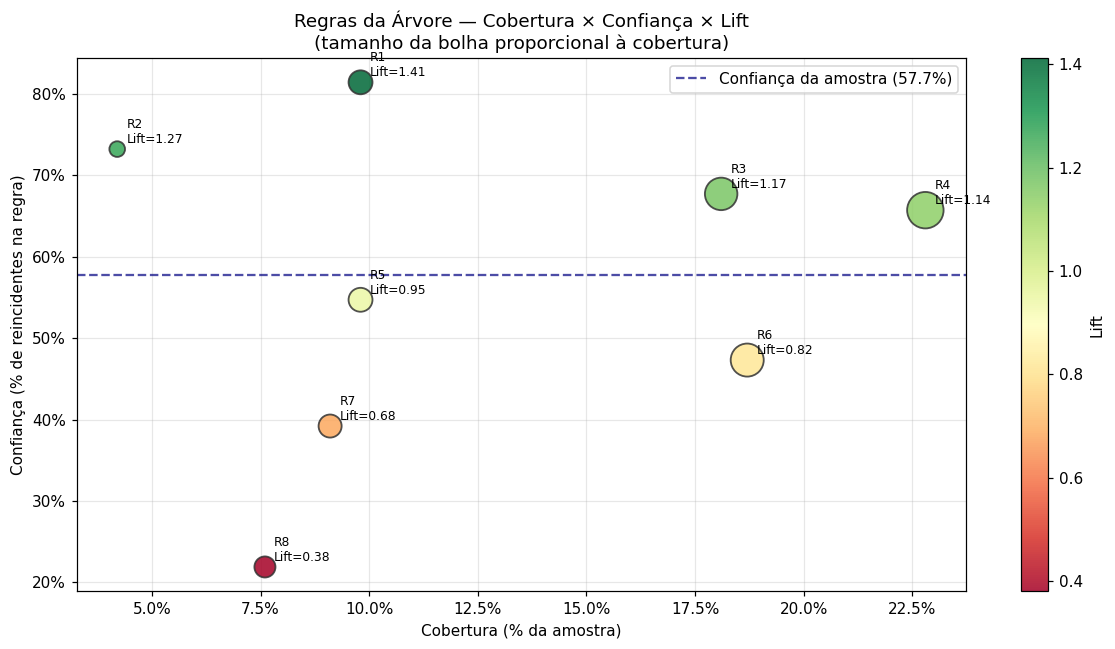

In [8]:
# Gráfico: Cobertura × Confiança × Lift (bolhas)
# Tamanho = cobertura | Cor = lift | Linha = confiança da amostra
fig, ax = plt.subplots(figsize=(11, 6))

coberturas = [r['cobertura_pct']  for r in regras_arvore]
confianças = [r['confianca_pct']  for r in regras_arvore]
lifts      = [r['lift']           for r in regras_arvore]

norm    = plt.Normalize(min(lifts), max(lifts))
scatter = ax.scatter(
    coberturas, confianças,
    s=[c * 25 for c in coberturas],
    c=lifts, cmap='RdYlGn', norm=norm,
    alpha=0.85, edgecolors='#333', linewidths=1.2, zorder=3
)

ax.axhline(p0 * 100, color='navy', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Confiança da amostra ({p0*100:.1f}%)')

for i, (cob, conf, lift) in enumerate(zip(coberturas, confianças, lifts), 1):
    ax.annotate(f'R{i}\nLift={lift:.2f}', (cob, conf),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

plt.colorbar(scatter, ax=ax, label='Lift')
ax.set_xlabel('Cobertura (% da amostra)')
ax.set_ylabel('Confiança (% de reincidentes na regra)')
ax.set_title('Regras da Árvore — Cobertura × Confiança × Lift\n'
             '(tamanho da bolha proporcional à cobertura)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 1.1 Efeito da profundidade no conjunto de regras

Quanto maior a profundidade, mais regras são geradas — cada uma mais específica (menor cobertura) e mais confiante. A profundidade controla diretamente o trade-off entre **generalidade** e **especificidade** das regras.

In [9]:
# =============================================================================
# EFEITO DA PROFUNDIDADE NO CONJUNTO DE REGRAS
# Mais profundidade = mais regras, maior confiança, menor cobertura
# =============================================================================

print(f"{'Depth':>6} {'Regras':>7} {'Sig.':>5} {'Cob.Média':>10} "
      f"{'Conf.Média':>11} {'Lift Máx':>9} {'Lift Mín':>9}")
print('─' * 65)

for depth in [2, 3, 4, 5, 6]:
    dt_d = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=SEED)
    dt_d.fit(X_train_sel, y_train)
    regs = extrair_regras_arvore(dt_d, VARS_SELECIONADAS,
                                  X_train_sel, y_train,
                                  X_test_sel, y_test)
    n_sig = sum(1 for r in regs if r['significativa'])
    print(f"{depth:>6} {len(regs):>7} {n_sig:>5} "
          f"{np.mean([r['cobertura_pct'] for r in regs]):>9.1f}% "
          f"{np.mean([r['confianca_pct'] for r in regs]):>10.1f}% "
          f"{max(r['lift'] for r in regs):>9.3f} "
          f"{min(r['lift'] for r in regs):>9.3f}")


 Depth  Regras  Sig.  Cob.Média  Conf.Média  Lift Máx  Lift Mín
─────────────────────────────────────────────────────────────────
     2       4     2      25.0%       55.4%     1.258     0.543
     3       8     4      12.5%       56.4%     1.412     0.380
     4      16     7       6.2%       55.3%     1.458     0.333
     5      32    15       3.1%       57.0%     1.733     0.079
     6      62    23       1.6%       58.2%     1.733     0.000


## Indução de Regras com o Algoritmo Apriori

A abordagem anterior extrai regras **da estrutura da árvore** — hierárquicas, sem sobreposição, cobrindo 100% da amostra. O **Apriori** funciona de forma diferente: busca diretamente combinações de condições frequentes nos dados, sem impor estrutura hierárquica.

| Aspecto | Árvore de Decisão | Apriori |
|---|---|---|
| **Estrutura** | Hierárquica (cada nível depende do anterior) | Plana (regras independentes) |
| **Cobertura** | 100% da amostra (toda folha cobre algum grupo) | Parcial (pode não cobrir todos os registros) |
| **Sobreposição** | Nenhuma — partição exclusiva | Possível — um registro pode satisfazer várias regras |
| **Inconsistência** | Impossível por construção | Possível — requer tratamento explícito |

O Apriori exige dados **binários**: cada coluna representa uma característica e indica presença (1) ou ausência (0). Por isso binarizamos cada variável selecionada pela sua mediana antes de aplicar o algoritmo.

In [10]:
# =============================================================================
# BINARIZAÇÃO PARA O APRIORI
# Cada variável vira binária: acima da mediana (1) ou abaixo/igual (0)
# =============================================================================

df_ap = X_train_sel.copy()
colunas_bin = {}
for col in VARS_SELECIONADAS:
    mediana = df_ap[col].median()
    nome    = f"{col}_alto"
    df_ap[nome] = (df_ap[col] > mediana).astype(bool)
    colunas_bin[col] = (nome, mediana)

df_ap['Reincidiu'] = y_train.values.astype(bool)
df_bin = df_ap[[v for v, _ in colunas_bin.values()] + ['Reincidiu']].copy()

print("Binarização das variáveis (coluna_alto = acima da mediana):")
for col, (nome, med) in colunas_bin.items():
    pct_alto = df_bin[nome].mean() * 100
    print(f"  {nome:<50} mediana={med:.3f}  alto={pct_alto:.1f}%")

# =============================================================================
# APRIORI — itemsets frequentes e regras de classificação
# min_support   : cobertura mínima (5% da amostra)
# min_threshold : confiança mínima (60%)
# =============================================================================

print("\nBuscando itemsets frequentes...")
itemsets = apriori(df_bin, min_support=0.05, use_colnames=True, verbose=0)
print(f"Itemsets frequentes encontrados: {len(itemsets)}")

print("Gerando regras de associação...")
regras_ap_todas = association_rules(
    itemsets, metric='confidence', min_threshold=0.60,
    num_itemsets=len(itemsets)
)

# Filtrar apenas regras de CLASSIFICAÇÃO: consequente = 'Reincidiu'
regras_ap = regras_ap_todas[
    regras_ap_todas['consequents'].apply(lambda x: 'Reincidiu' in x)
].copy()

# Lift ajustado em relação à taxa base (confiança da amostra)
regras_ap = regras_ap.copy()
regras_ap['lift_ajustado'] = regras_ap['confidence'] / p0
regras_ap = regras_ap.sort_values('lift_ajustado', ascending=False).reset_index(drop=True)

print(f"\nRegras de classificação (consequente=Reincidiu, conf≥60%): {len(regras_ap)}")


Binarização das variáveis (coluna_alto = acima da mediana):
  Jobs_Per_Year_alto                                 mediana=0.635  alto=48.3%
  Avg_Days_per_DrugTest_alto                         mediana=55.425  alto=38.4%
  Prior_Arrest_Episodes_Felony_alto                  mediana=5.000  alto=49.2%
  Age_at_Release_alto                                mediana=3.000  alto=36.2%
  Supervision_Risk_Score_First_alto                  mediana=6.000  alto=43.6%

Buscando itemsets frequentes...
Itemsets frequentes encontrados: 43
Gerando regras de associação...

Regras de classificação (consequente=Reincidiu, conf≥60%): 11


In [11]:
# =============================================================================
# EXIBIÇÃO DAS REGRAS DO APRIORI com métricas do professor
# =============================================================================

print(f"Confiança da amostra: {p0*100:.1f}%\n")

for i, row in regras_ap.head(10).iterrows():
    antec = sorted(list(row['antecedents']))
    conf  = row['confidence'] * 100
    sup   = row['support']   * 100
    lift  = row['lift_ajustado']
    N_C   = int(round(row['support'] * len(df_bin)))
    N_AC  = int(round(row['confidence'] * N_C))
    pv    = binomtest(N_AC, N_C, p0, alternative='greater').pvalue

    print(f"{'='*65}")
    print(f"Regra {i+1:>2}  |  Predição: Reincidiu")
    print(f"{'─'*65}")
    for ant in antec:
        col_orig = ant.replace('_alto', '')
        med_val  = colunas_bin.get(col_orig, (None, '?'))[1]
        print(f"  SE  {ant}  (> {med_val:.3f})")
    print(f"{'─'*65}")
    print(f"  Cobertura   (N_C/N)     : {sup:>5.1f}%  ({N_C:,} registros)")
    print(f"  Confiança   (N_AC/N_C)  : {conf:>5.1f}%  (amostra: {p0*100:.1f}%)")
    print(f"  Lift                    : {lift:>5.3f}  "
          f"({'↑ acima da média' if lift>1 else '↓ abaixo da média'})")
    print(f"  Significância (p-value) : {pv:.2e}  "
          f"{'✓ Significativa' if pv < 0.05 else '✗ Não significativa'}")
    print()

# Tabela resumo
rows_ap = []
for i, row in regras_ap.iterrows():
    N_C  = int(round(row['support'] * len(df_bin)))
    N_AC = int(round(row['confidence'] * N_C))
    pv   = binomtest(N_AC, N_C, p0, alternative='greater').pvalue
    rows_ap.append({
        'Regra'         : i + 1,
        'Antecedentes'  : ' E '.join(sorted(list(row['antecedents']))),
        'Cobertura (%)'  : round(row['support']       * 100, 1),
        'Confiança (%)'  : round(row['confidence']     * 100, 1),
        'Lift'           : round(row['lift_ajustado'],  3),
        'p-value'        : f"{pv:.2e}",
        'Sig.'           : '✓' if pv < 0.05 else '✗',
    })

df_resumo_ap = pd.DataFrame(rows_ap).set_index('Regra')
display(df_resumo_ap)


Confiança da amostra: 57.7%

Regra  1  |  Predição: Reincidiu
─────────────────────────────────────────────────────────────────
  SE  Jobs_Per_Year_alto  (> 0.635)
  SE  Prior_Arrest_Episodes_Felony_alto  (> 5.000)
  SE  Supervision_Risk_Score_First_alto  (> 6.000)
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)     :   7.9%  (1,429 registros)
  Confiança   (N_AC/N_C)  :  71.9%  (amostra: 57.7%)
  Lift                    : 1.247  (↑ acima da média)
  Significância (p-value) : 4.69e-29  ✓ Significativa

Regra  2  |  Predição: Reincidiu
─────────────────────────────────────────────────────────────────
  SE  Prior_Arrest_Episodes_Felony_alto  (> 5.000)
  SE  Supervision_Risk_Score_First_alto  (> 6.000)
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)     :  15.9%  (2,870 registros)
  Confiança   (N_AC/N_C)  :  70.8%  (amostra: 57.7%)
  Lift                    : 1.228  (↑ acima da média)
  Significância (p-value

,Antecedentes,Cobertura (%),Confiança (%),Lift,p-value,Sig.
Regra,,,,,,
1,Jobs_Per_Year_alto E Prior_Arrest_Episodes_Felony_alto E Supervision_Risk_Score_First_...,7.9,71.9,1.247,4.69e-29,✓
2,Prior_Arrest_Episodes_Felony_alto E Supervision_Risk_Score_First_alto,15.9,70.8,1.228,3.89e-48,✓
3,Avg_Days_per_DrugTest_alto E Prior_Arrest_Episodes_Felony_alto E Supervision_Risk_Scor...,6.2,70.0,1.214,1.00e-17,✓
4,Jobs_Per_Year_alto E Prior_Arrest_Episodes_Felony_alto,15.7,66.7,1.157,3.90e-23,✓
5,Jobs_Per_Year_alto E Supervision_Risk_Score_First_alto,14.3,66.5,1.153,1.79e-20,✓
6,Supervision_Risk_Score_First_alto,28.9,66.4,1.151,2.10e-38,✓
7,Prior_Arrest_Episodes_Felony_alto,32.3,65.7,1.139,3.08e-36,✓
8,Avg_Days_per_DrugTest_alto E Jobs_Per_Year_alto E Prior_Arrest_Episodes_Felony_alto,5.4,65.4,1.133,4.54e-07,✓
9,Avg_Days_per_DrugTest_alto E Supervision_Risk_Score_First_alto,11.0,65.0,1.126,2.05e-11,✓


### 2.1 Consistência e cobertura do Apriori

Diferente da árvore, o Apriori pode gerar regras inconsistentes (mesmo perfil levando a predições opostas) e não cobre necessariamente 100% da amostra. Os registros não cobertos por nenhuma regra recebem a **regra default** — predizer a classe majoritária.

In [12]:
# =============================================================================
# VERIFICAÇÃO DE CONSISTÊNCIA E COBERTURA DO APRIORI
# =============================================================================

# Pares de regras com antecedentes sobrepostos mas consequentes distintos
# (inconsistência: o mesmo perfil leva a predições diferentes)
todas_regras_ap = association_rules(
    itemsets, metric='confidence', min_threshold=0.0,
    num_itemsets=len(itemsets)
)
n_conflitos = 0
for i in range(len(todas_regras_ap)):
    for j in range(i+1, len(todas_regras_ap)):
        r1, r2 = todas_regras_ap.iloc[i], todas_regras_ap.iloc[j]
        if (r1['antecedents'] & r2['antecedents']) and r1['consequents'] != r2['consequents']:
            n_conflitos += 1

print(f"Pares inconsistentes (antecedentes sobrepostos, consequentes distintos): {n_conflitos}")

# Cobertura total do conjunto de regras gerado
cobertos = set()
for _, row in regras_ap.iterrows():
    mask = pd.Series([True] * len(df_bin), index=df_bin.index)
    for ant in row['antecedents']:
        mask = mask & df_bin[ant]
    cobertos.update(df_bin[mask].index.tolist())

pct_cob = len(cobertos) / len(df_bin) * 100
print(f"\nCobertura total das {len(regras_ap)} regras do Apriori:")
print(f"  Registros cobertos       : {len(cobertos):,} ({pct_cob:.1f}%)")
print(f"  Sem cobertura (default)  : {len(df_bin)-len(cobertos):,} ({100-pct_cob:.1f}%)")
print(f"  Regra default            : Reincidiu ({p0*100:.1f}% — classe majoritária)")

print(f"\n{'─'*50}")
print("Comparativo final:")
print(f"  Árvore (depth=3): {len(regras_arvore)} regras, cobertura=100%, "
      f"lift_máx={max(r['lift'] for r in regras_arvore):.3f}")
print(f"  Apriori         : {len(regras_ap)} regras, cobertura={pct_cob:.1f}%, "
      f"lift_máx={regras_ap['lift_ajustado'].max():.3f}")


Pares inconsistentes (antecedentes sobrepostos, consequentes distintos): 7654

Cobertura total das 11 regras do Apriori:
  Registros cobertos       : 12,720 (70.3%)
  Sem cobertura (default)  : 5,364 (29.7%)
  Regra default            : Reincidiu (57.7% — classe majoritária)

──────────────────────────────────────────────────
Comparativo final:
  Árvore (depth=3): 8 regras, cobertura=100%, lift_máx=1.412
  Apriori         : 11 regras, cobertura=70.3%, lift_máx=1.247
